In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.


# -----------------------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -----------------------------------------------

import tensorflow as tf
from tensorflow.keras.models import Sequential 
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).


from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.


from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).



In [3]:
df = pd.read_csv('Iris.csv')

In [27]:
df.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
92,93,5.8,2.6,4.0,1.2,Iris-versicolor
32,33,5.2,4.1,1.5,0.1,Iris-setosa
33,34,5.5,4.2,1.4,0.2,Iris-setosa
107,108,7.3,2.9,6.3,1.8,Iris-virginica
8,9,4.4,2.9,1.4,0.2,Iris-setosa
100,101,6.3,3.3,6.0,2.5,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
48,49,5.3,3.7,1.5,0.2,Iris-setosa
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
46,47,5.1,3.8,1.6,0.2,Iris-setosa


In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


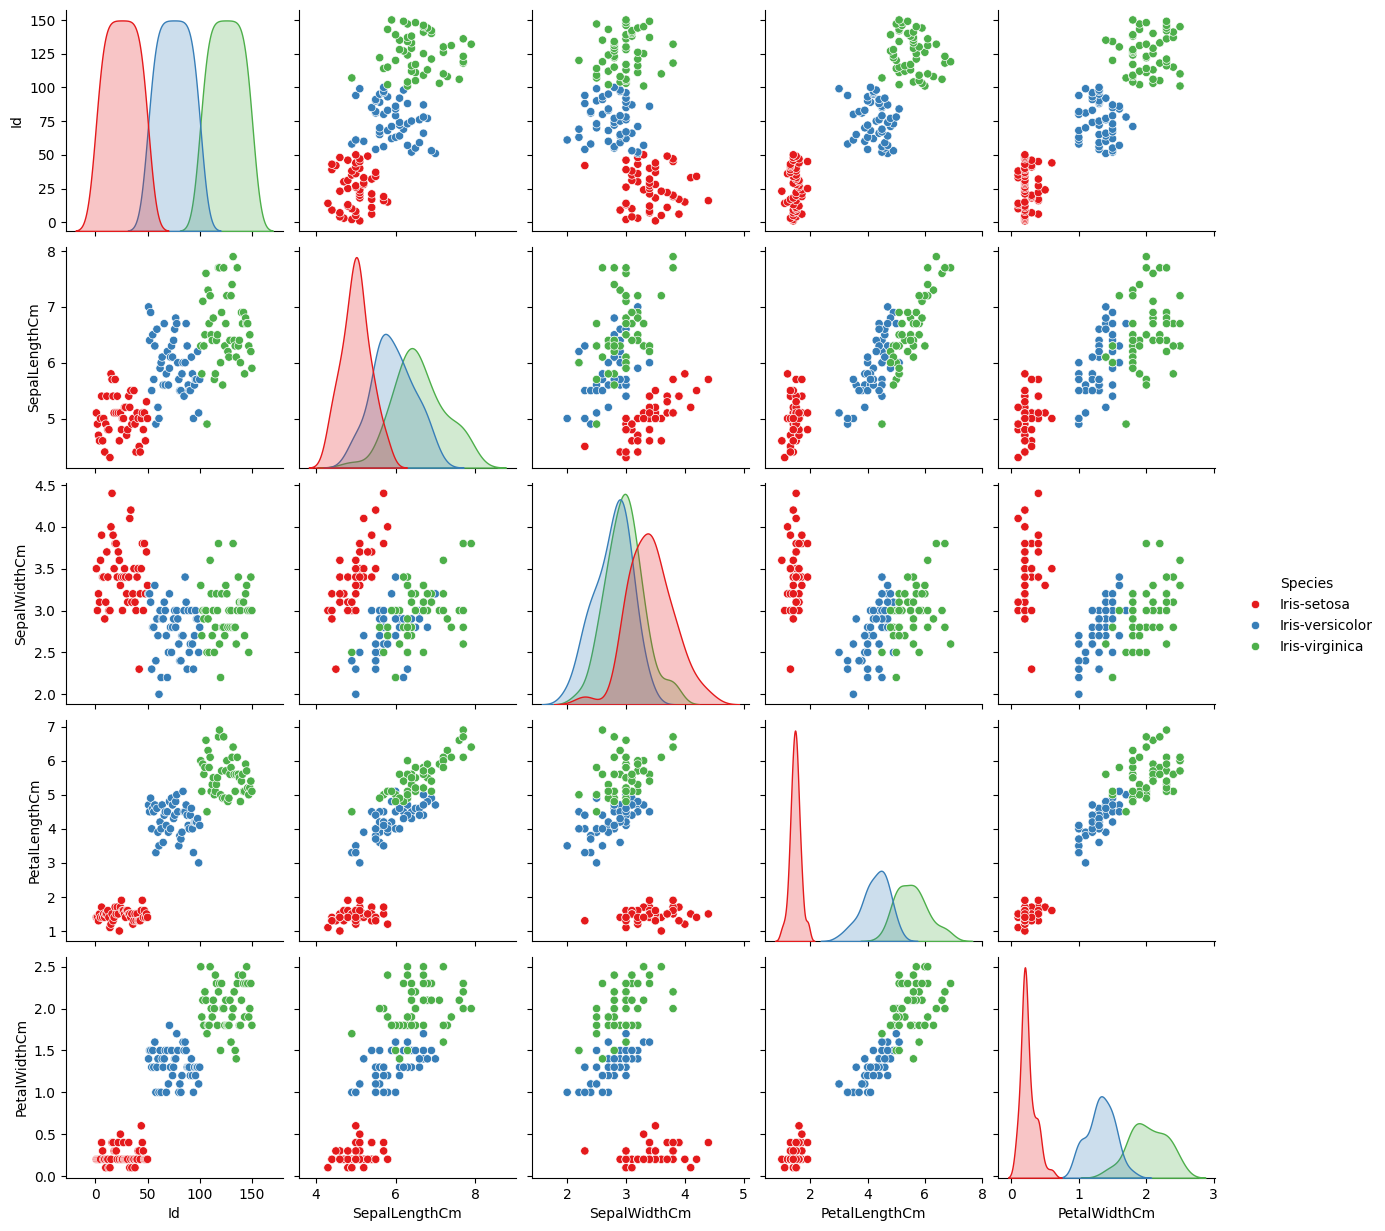

In [8]:
sns.pairplot(df, hue='Species', palette='Set1')

In [12]:
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

In [13]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

In [14]:
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42,stratify = y_int)   

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
per = Perceptron(max_iter=1000, random_state=42)
per.fit(X_train_scaled, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [19]:
y_pred_per = per.predict(X_test_scaled)

In [21]:
accuracy_per = accuracy_score(y_test, y_pred_per)
accuracy_per

0.8666666666666667

In [22]:
print(classification_report(y_test, y_pred_per))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



In [23]:
y_train_cat = to_categorical(y_train,num_classes=3)
y_test_cat = to_categorical(y_test,num_classes=3)


In [24]:
y_train_cat

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0

In [28]:
model = Sequential([
    Dense(16, input_dim = 4 , activation = 'relu'),
    Dense(8, activation = 'relu'),
    Dense(3, activation = 'softmax')
])

In [30]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [31]:
history = model.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=8, validation_split=0.2 ,verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5312 - loss: 0.9552 - val_accuracy: 0.5833 - val_loss: 0.8898
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5521 - loss: 0.8839 - val_accuracy: 0.5833 - val_loss: 0.8355
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5521 - loss: 0.8331 - val_accuracy: 0.6250 - val_loss: 0.7924
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5521 - loss: 0.7913 - val_accuracy: 0.6667 - val_loss: 0.7565
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5938 - loss: 0.7556 - val_accuracy: 0.7083 - val_loss: 0.7269
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6979 - loss: 0.7244 - val_accuracy: 0.8333 - val_loss: 0.7008
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8229 - loss: 0.6970 - val_accuracy: 0.8333 - val_loss: 0.6791
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8542 - loss: 0.6723 - val_accuracy: 0.8750 - 

In [32]:
loss , acc = model.evaluate(X_test_scaled, y_test_cat)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9667 - loss: 0.0951
0.9666666388511658


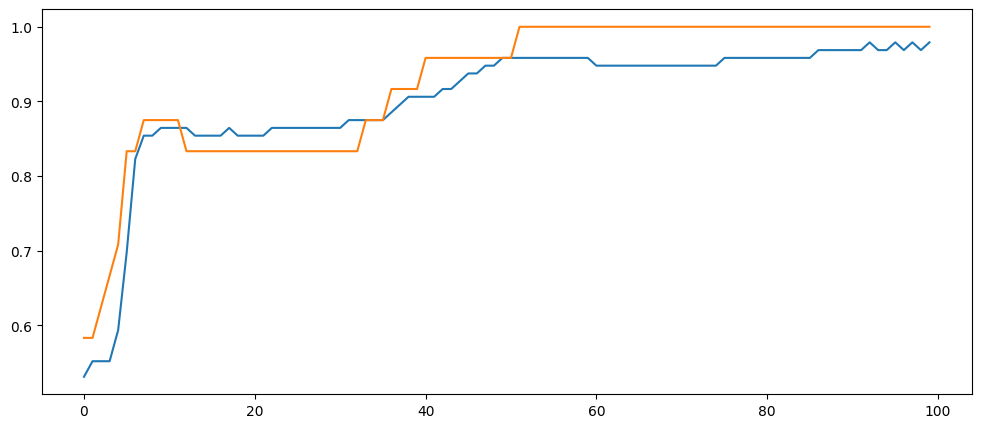

In [34]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


In [ ]:
y